# BERT/RoBERTa Run From Preprocessed Data



This notebook rumns transformer experiments: raw_text and clean_text. The goal is to compare whether transformer performance improves or worsens when using cleaned text.

## 1. Install Libraries

Use this in Google Colab Pro. The dataset is already preprocessed, so this notebook does not reload the full Hugging Face dataset.

In [ ]:
!pip -q install datasets transformers accelerate scikit-learn pandas matplotlib seaborn torch

## 2. Imports and Configuration

In [ ]:
import os
import inspect
import json
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from datasets import Dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [ ]:
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

LABEL_NAMES = ["right", "right-center", "least-biased", "left-center", "left"]
ID_TO_LABEL = dict(enumerate(LABEL_NAMES))
LABEL_TO_ID = {name: i for i, name in ID_TO_LABEL.items()}

DRIVE_ROOT = "/content/my_drive"
PREPROCESSING_DIR = f"{DRIVE_ROOT}/MyDrive/cs4650_finalproj/chethas_preprocessing_outputs"
BERT_OUTPUT_DIR = f"{DRIVE_ROOT}/MyDrive/cs4650_finalproj/bert_raw_vs_clean_outputs"


os.makedirs(BERT_OUTPUT_DIR, exist_ok=True)

# roberta-base matches the teammate notebook. Change to "bert-base-uncased" if your group wants literal BERT.
MODEL_NAME = "roberta-base"
MAX_LEN = 512

NUM_EPOCHS = 3
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

os.makedirs(BERT_OUTPUT_DIR, exist_ok=True)

## 3. Mount Google Drive and Load Preprocessed CSVs

This expects train_processed.csv and val_processed.csv

In [ ]:
import shutil
import os

if os.path.exists("/content/my_drive"):
    shutil.rmtree("/content/my_drive")

from google.colab import drive

DRIVE_ROOT = "/content/my_drive"
drive.mount(DRIVE_ROOT)


Mounted at /content/my_drive


In [ ]:
train_path = os.path.join(PREPROCESSING_DIR, "train_processed.csv")
val_path = os.path.join(PREPROCESSING_DIR, "val_processed.csv")

print("Train path:", train_path)
print("Validation path:", val_path)

train_processed = pd.read_csv(train_path)
val_processed = pd.read_csv(val_path)

print(train_processed.shape)
print(val_processed.shape)
train_processed.head()

Train path: /content/my_drive/MyDrive/cs4650_finalproj/chethas_preprocessing_outputs/train_processed.csv
Validation path: /content/my_drive/MyDrive/cs4650_finalproj/chethas_preprocessing_outputs/val_processed.csv
(20000, 8)
(4000, 8)


,split,title,raw_text,clean_text,label,label_name,raw_word_count,clean_word_count
0,train,Presumed guilty,"Presumed guilty. <p>Not long ago, my wife Helm...",presumed guilty long ago wife helm one morning...,3,left-center,787,362
1,train,A Judge Just Sentenced the Millionaire Montana...,A Judge Just Sentenced the Millionaire Montana...,judge sentenced millionaire montana politician...,4,left,254,157
2,train,More bodies found in Mexican grave,More bodies found in Mexican grave. <p>..........,body found mexican grave mexico city number ex...,2,least-biased,193,95
3,train,Primary Campaigns Coming to the Finish Line,Primary Campaigns Coming to the Finish Line. <...,primary campaign coming finish line polling pl...,2,least-biased,447,277
4,train,Bush Poaches a Longtime Clinton Backer,Bush Poaches a Longtime Clinton Backer. <p>Lyn...,bush poaches longtime clinton backer lynne sla...,4,left,921,566


## 4. Sanity Checks

Confirm that both raw and cleaned text are available and that labels match the five-class task.

In [ ]:
required_cols = ["raw_text", "clean_text", "label", "label_name"]
missing = [col for col in required_cols if col not in train_processed.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Train labels:")
print(train_processed["label_name"].value_counts().reindex(LABEL_NAMES))

print("\nValidation labels:")
print(val_processed["label_name"].value_counts().reindex(LABEL_NAMES))

print("\nRaw text sample:")
print(train_processed.loc[0, "raw_text"][:500])

print("\nClean text sample:")
print(train_processed.loc[0, "clean_text"][:500])

Train labels:
label_name
right           4000
right-center    4000
least-biased    4000
left-center     4000
left            4000
Name: count, dtype: int64

Validation labels:
label_name
right           800
right-center    800
least-biased    800
left-center     800
left            800
Name: count, dtype: int64

Raw text sample:
Presumed guilty. <p>Not long ago, my wife Helms and I were having one of those mornings where nothing is going quite right. We were late for everything, we weren&#8217;t getting things done, and to top it off, we had forgotten to grab our lunches from home in our haste to get out the door. As lunchtime approached, Helms expressed that on this particular day, food was not optional. There would be no unexpected fasting. So I ran out quickly to the nearby sandwich and coffee shop to grab a sandwich

Clean text sample:
presumed guilty long ago wife helm one morning nothing going quite right late everything getting thing done top forgotten grab lunch home haste get 

## 5. Tokenizer and First-512 Strategy

We use only the first truncation strategy because the saved teammate results showed it had the best macro-F1 and accuracy among first, last, and first-plus-last. For each text column, the tokenizer keeps the first 512 transformer tokens.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_first_batch(batch, text_col):
    return tokenizer(
        batch[text_col],
        truncation=True,
        max_length=MAX_LEN,
    )

def make_hf_datasets(text_col):
    train_df = train_processed[[text_col, "label"]].rename(columns={text_col: "text"}).copy()
    val_df = val_processed[[text_col, "label"]].rename(columns={text_col: "text"}).copy()

    train_df["text"] = train_df["text"].fillna("").astype(str)
    val_df["text"] = val_df["text"].fillna("").astype(str)
    train_df["label"] = train_df["label"].astype(int)
    val_df["label"] = val_df["label"].astype(int)

    train_ds = Dataset.from_pandas(train_df, preserve_index=False)
    val_ds = Dataset.from_pandas(val_df, preserve_index=False)

    train_tok = train_ds.map(lambda batch: tokenize_first_batch(batch, "text"), batched=True)
    val_tok = val_ds.map(lambda batch: tokenize_first_batch(batch, "text"), batched=True)

    return train_tok, val_tok

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## 6. Metrics and Training Helpers

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

def build_training_args(output_dir):
    sig = inspect.signature(TrainingArguments.__init__)
    kwargs = {
        "output_dir": output_dir,
        "learning_rate": LEARNING_RATE,
        "per_device_train_batch_size": TRAIN_BATCH_SIZE,
        "per_device_eval_batch_size": EVAL_BATCH_SIZE,
        "num_train_epochs": NUM_EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "logging_steps": 50,
        "save_strategy": "epoch",
        "load_best_model_at_end": True,
        "metric_for_best_model": "macro_f1",
        "greater_is_better": True,
        "report_to": "none",
        "seed": SEED,
    }

    if "eval_strategy" in sig.parameters:
        kwargs["eval_strategy"] = "epoch"
    else:
        kwargs["evaluation_strategy"] = "epoch"

    return TrainingArguments(**kwargs)

def make_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABEL_NAMES),
        id2label=ID_TO_LABEL,
        label2id=LABEL_TO_ID,
    )

## 7. Run One Experiment

This function trains and evaluates the transformer for either raw_text or clean_text, then saves metrics, predictions, confusion matrix, and the best model to Drive.

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
all_results = []

def make_trainer(model, training_args, train_tok, val_tok):
    trainer_kwargs = {
        "model": model,
        "args": training_args,
        "train_dataset": train_tok,
        "eval_dataset": val_tok,
        "data_collator": data_collator,
        "compute_metrics": compute_metrics,
    }

    trainer_sig = inspect.signature(Trainer.__init__)
    if "processing_class" in trainer_sig.parameters:
        trainer_kwargs["processing_class"] = tokenizer
    elif "tokenizer" in trainer_sig.parameters:
        trainer_kwargs["tokenizer"] = tokenizer

    return Trainer(**trainer_kwargs)

def run_experiment(text_col):
    experiment_name = f"{MODEL_NAME.replace('/', '-')}_first_{text_col}"
    output_dir = os.path.join(BERT_OUTPUT_DIR, experiment_name)
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n===== Running {experiment_name} =====")
    train_tok, val_tok = make_hf_datasets(text_col)

    model = make_model()
    training_args = build_training_args(output_dir)

    trainer = make_trainer(model, training_args, train_tok, val_tok)

    trainer.train()
    eval_metrics = trainer.evaluate()

    prediction_output = trainer.predict(val_tok)
    preds = np.argmax(prediction_output.predictions, axis=-1)
    labels = prediction_output.label_ids

    macro = f1_score(labels, preds, average="macro")
    acc = accuracy_score(labels, preds)
    report = classification_report(labels, preds, target_names=LABEL_NAMES, zero_division=0)
    cm = confusion_matrix(labels, preds, labels=list(range(len(LABEL_NAMES))))

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro:.4f}")
    print(report)

    metrics = {
        "experiment": experiment_name,
        "model_name": MODEL_NAME,
        "text_col": text_col,
        "strategy": "first",
        "accuracy": float(acc),
        "macro_f1": float(macro),
    }

    all_results.append(metrics)
    return metrics, trainer


## 8. Run Raw Text Experiment


In [ ]:
raw_metrics, raw_trainer = run_experiment("raw_text")


===== Running roberta-base_first_raw_text =====


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.375446,3.218841,0.279250,0.247589
2,0.222839,3.901180,0.281750,0.269010
3,0.176844,4.604982,0.286250,0.281016


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.2863
Macro F1: 0.2810
              precision    recall  f1-score   support

       right       0.43      0.38      0.40       800
right-center       0.33      0.19      0.24       800
least-biased       0.21      0.08      0.12       800
 left-center       0.40      0.46      0.43       800
        left       0.16      0.33      0.22       800

    accuracy                           0.29      4000
   macro avg       0.31      0.29      0.28      4000
weighted avg       0.31      0.29      0.28      4000



## 9. Run Clean Text Experiment

This tests whether the preprocessing pipeline helps or hurts the transformer model.

In [ ]:
clean_metrics, clean_trainer = run_experiment("clean_text")


===== Running roberta-base_first_clean_text =====


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.529554,2.452305,0.244250,0.222890
2,0.422061,2.675308,0.304500,0.292884
3,0.303830,3.589173,0.298500,0.290268


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Accuracy: 0.3048
Macro F1: 0.2936
              precision    recall  f1-score   support

       right       0.43      0.36      0.39       800
right-center       0.36      0.30      0.33       800
least-biased       0.23      0.05      0.08       800
 left-center       0.40      0.39      0.40       800
        left       0.20      0.43      0.27       800

    accuracy                           0.30      4000
   macro avg       0.32      0.30      0.29      4000
weighted avg       0.32      0.30      0.29      4000



## 10. Compare Raw vs Clean

In [ ]:
comparison_df = pd.DataFrame(all_results).sort_values("macro_f1", ascending=False)
comparison_path = os.path.join(BERT_OUTPUT_DIR, "raw_vs_clean_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

print(comparison_path)
comparison_df[["experiment", "text_col", "accuracy", "macro_f1"]]

/content/my_drive/MyDrive/cs4650_finalproj/bert_raw_vs_clean_outputs/raw_vs_clean_comparison.csv


,experiment,text_col,accuracy,macro_f1
1,roberta-base_first_clean_text,clean_text,0.30475,0.293574
0,roberta-base_first_raw_text,raw_text,0.28625,0.281016


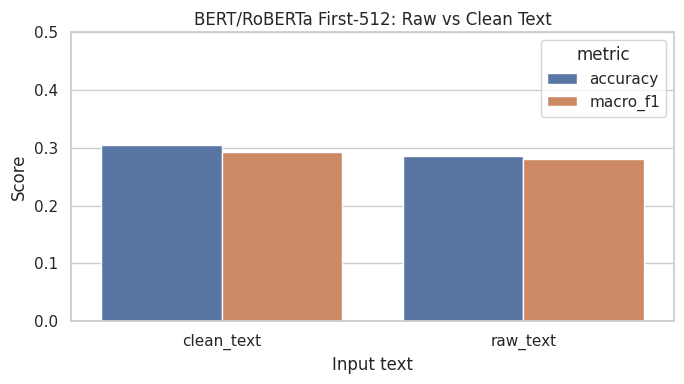

In [ ]:
plt.figure(figsize=(7, 4))
plot_df = comparison_df.melt(
    id_vars=["text_col"],
    value_vars=["accuracy", "macro_f1"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=plot_df, x="text_col", y="score", hue="metric")
plt.ylim(0, max(0.5, plot_df["score"].max() + 0.05))
plt.title("BERT/RoBERTa First-512: Raw vs Clean Text")
plt.xlabel("Input text")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(os.path.join(BERT_OUTPUT_DIR, "raw_vs_clean_scores.png"), dpi=200, bbox_inches="tight")
plt.show()